In [ ]:
import pandas as pd

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print("--- INFORMACIJE O TRENING SETU ---")
train_info = train_df.info()

print("\n--- PROVERA NEDOSTAJUĆIH VREDNOSTI (TRAIN) ---")
print(train_df.isnull().sum())

print("\n--- PRVIH 5 REDOVA ---")
print(train_df.head())

print("\n--- STATISTIČKI PREGLED NUMERIČKIH PODATAKA ---")
print(train_df.describe())

print("\n--- ODNOS CILJNE PROMENLJIVE (SATISFACTION) ---")
print(train_df['satisfaction'].value_counts())

--- INFORMACIJE O TRENING SETU ---
<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location  

In [9]:
# 1. Brisanje (ovo ostaje isto jer radimo nad celim df, ne nad kolonom)
# Ako si već obrisala ove kolone u prethodnom pokušaju, ovaj deo će baciti grešku, 
# u tom slučaju ga samo preskoči.
columns_to_drop = ['Unnamed: 0', 'id']
train_df.drop(columns=[col for col in columns_to_drop if col in train_df.columns], inplace=True)
test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns], inplace=True)

# 2. Popunjavanje NaN vrednosti - direktna dodela (bez inplace=True)
medijana_kasnjenja = train_df['Arrival Delay in Minutes'].median()

train_df['Arrival Delay in Minutes'] = train_df['Arrival Delay in Minutes'].fillna(medijana_kasnjenja)
test_df['Arrival Delay in Minutes'] = test_df['Arrival Delay in Minutes'].fillna(medijana_kasnjenja)

# 3. Provera - sada bi trebalo da bude 0
print("Preostali NaN u Train:", train_df.isnull().sum().sum())
print("Preostali NaN u Test:", test_df.isnull().sum().sum())

Preostali NaN u Train: 0
Preostali NaN u Test: 0


In [14]:
from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding za binarne kolone
binary_cols = ['Gender', 'Customer Type', 'Type of Travel', 'satisfaction']
le = LabelEncoder()

for col in binary_cols:
    if col in train_df.columns:
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        test_df[col] = le.transform(test_df[col].astype(str))

# 2. One-Hot Encoding za 'Class' (samo ako kolona još uvek postoji)
if 'Class' in train_df.columns:
    train_df = pd.get_dummies(train_df, columns=['Class'], dtype=int)
    test_df = pd.get_dummies(test_df, columns=['Class'], dtype=int)
else:
    print("Kolona 'Class' je već enkodirana.")

# 3. Finalno pretvaranje u float da bi skaliranje radilo bez greške
train_df = train_df.astype(float)
test_df = test_df.astype(float)

print("Trenutne kolone u datasetu:\n", train_df.columns.tolist())

Kolona 'Class' je već enkodirana.
Trenutne kolone u datasetu:
 ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction', 'Class_Business', 'Class_Eco', 'Class_Eco Plus']


In [15]:
# 1. Odvajanje ciljne promenljive (y)
y_train = train_df['satisfaction']
y_test = test_df['satisfaction']

# 2. Odvajanje ulaznih podataka (X)
X_train = train_df.drop('satisfaction', axis=1)
X_test = test_df.drop('satisfaction', axis=1)

# 3. Min-Max Skaliranje po tvojoj formuli
min_val = X_train.min()
max_val = X_train.max()
opseg = max_val - min_val

# Skaliranje
X_train_scaled = (X_train - min_val) / opseg
X_test_scaled = (X_test - min_val) / opseg

print("Skaliranje uspešno završeno!")
print(X_train_scaled.head())

Skaliranje uspešno završeno!
   Gender  Customer Type       Age  Type of Travel  Flight Distance  \
0     1.0            0.0  0.076923             1.0         0.086632   
1     1.0            1.0  0.230769             0.0         0.041195   
2     0.0            0.0  0.243590             0.0         0.224354   
3     0.0            0.0  0.230769             0.0         0.107229   
4     1.0            0.0  0.692308             0.0         0.036955   

   Inflight wifi service  Departure/Arrival time convenient  \
0                    0.6                                0.8   
1                    0.6                                0.4   
2                    0.4                                0.4   
3                    0.4                                1.0   
4                    0.6                                0.6   

   Ease of Online booking  Gate location  Food and drink  ...  \
0                     0.6            0.2             1.0  ...   
1                     0.6          

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Inicijalizacija modela
model = Sequential()

# Popravka: Dodavanje Input sloja kao prvog elementa (24 kolone u X_train_scaled)
model.add(Input(shape=(24,)))

# Prvi skriveni sloj
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.2))

# Drugi skriveni sloj
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))

# Izlazni sloj za binarnu klasifikaciju
model.add(Dense(units=1, activation='sigmoid'))

# Kompilacija modela
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

Trening je počeo...
Epoch 1/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8923 - loss: 0.2693 - val_accuracy: 0.9309 - val_loss: 0.1714
Epoch 2/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9293 - loss: 0.1770 - val_accuracy: 0.9438 - val_loss: 0.1428
Epoch 3/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9390 - loss: 0.1517 - val_accuracy: 0.9484 - val_loss: 0.1242
Epoch 4/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9427 - loss: 0.1399 - val_accuracy: 0.9470 - val_loss: 0.1260
Epoch 5/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9461 - loss: 0.1323 - val_accuracy: 0.9523 - val_loss: 0.1134
Epoch 6/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9477 - loss: 0.1274 - val_accuracy: 0.9519 - val_loss: 0.1132
Epoch 7/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9494 - loss: 0.1233 - val_accuracy: 0.9552 - val_loss: 0.1080
Epoch 8/50
3247/3247 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accurac

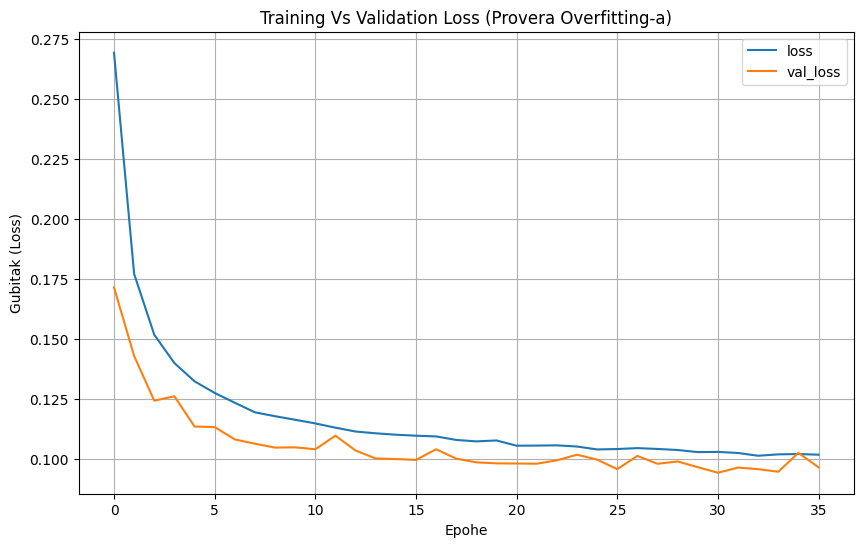

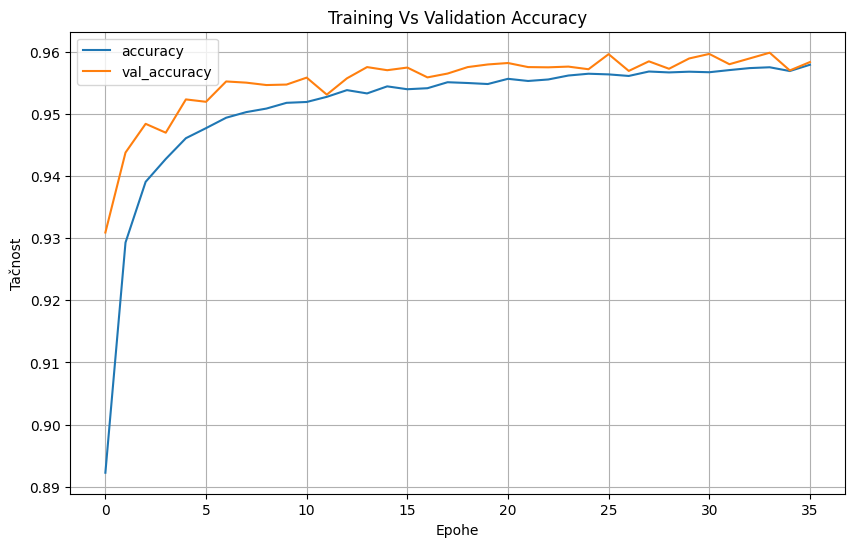

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Definisanje Early Stopping-a da sprečimo overfitting
# patience=5 znači: "Ako se 5 epoha zaredom ne popravi val_loss, prekini trening"
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

# 2. Pokretanje treninga (Ovde se stvara varijabla 'history')
print("Trening je počeo...")
history = model.fit(
    x=X_train_scaled, 
    y=y_train, 
    epochs=50, 
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1
)
# Kreiranje DataFrame-a od istorije treninga
loss_df = pd.DataFrame(history.history)

# Grafik za Loss (Gubitak)
loss_df.loc[:, ['loss', 'val_loss']].plot(figsize=(10, 6))
plt.title('Training Vs Validation Loss (Provera Overfitting-a)')
plt.xlabel('Epohe')
plt.ylabel('Gubitak (Loss)')
plt.grid(True)
plt.show()

# Grafik za Accuracy (Tačnost)
loss_df.loc[:, ['accuracy', 'val_accuracy']].plot(figsize=(10, 6))
plt.title('Training Vs Validation Accuracy')
plt.xlabel('Epohe')
plt.ylabel('Tačnost')
plt.grid(True)
plt.show()

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- IZVEŠTAJ KLASIFIKACIJE ---
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96     14573
         1.0       0.97      0.93      0.95     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



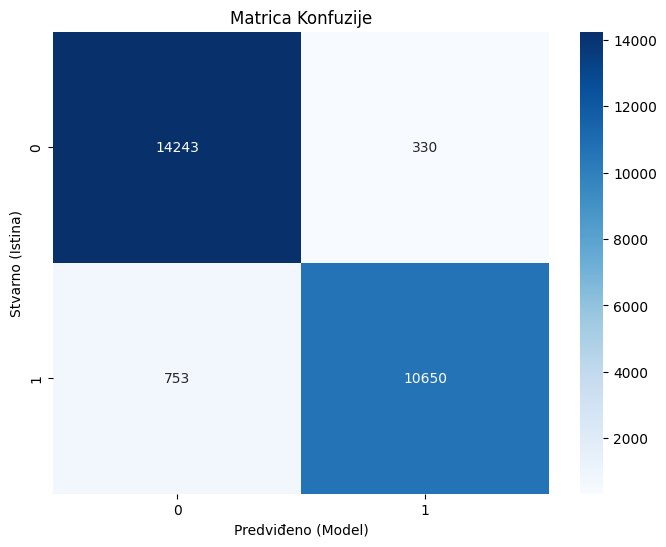

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Predviđanje na test podacima
# Model vraća verovatnoće (npr. 0.98), pa ih pretvaramo u 0 ili 1
predictions = (model.predict(X_test_scaled) > 0.5).astype("int32")

# 2. Ispis tekstualnog izveštaja
print("--- IZVEŠTAJ KLASIFIKACIJE ---")
print(classification_report(y_test, predictions))

# 3. Vizuelizacija Matrice Konfuzije
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrica Konfuzije')
plt.xlabel('Predviđeno (Model)')
plt.ylabel('Stvarno (Istina)')
plt.show()